## K-Nearest Neighbors (KNN)

K-nearest neighbors is a technique that, given a new point, looks at its k nearest neighbors to see what label it is closest to. The method used to find the closest neighbors is Euclidean distance, which is denoted by:

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

An important step is making sure to have a k value that is just right.
- a k-value too small leads to overfitting
- a k-value too big leads to underfitting
- the goal is to have a k value that balances the two

KNN differs from other systems due to the fact that it has no weights, biases, or gradient descent. It simply just uses the nearest points to determine what to classify the new data as.  
  
Another important factor to consider is due to the possibility of having multiple features, each on their own scale. It is crucial to standardize the data or else data with bigger numbers will trump out the data with smaller numbers.  

In [28]:
import numpy as np
from collections import Counter
import pandas as pd
from sklearn.preprocessing import StandardScaler


class KNN:
    def __init__(self, k=5):
        self.k = k
    
    def euclidean_distance(self, x1, x2):
        return np.linalg.norm(x1-x2)
    def fit(self, x_train, y_train):
        self.x_train = np.array(x_train)
        self.y_train = np.array(y_train)
        
    def predict(self, X):
        X=np.array(X)
        return np.array([self._predict_one(x) for x in X])

    def _predict_one(self,x):
        distances = np.sqrt(np.sum((self.x_train - x)**2, axis=1))
        
        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]
    
scaler = StandardScaler()


df = pd.read_csv('../data/TShirt_size.csv')
df['T Shirt Size'] = df['T Shirt Size'].map({"M": 1, "L": 2})
print(df)

x_train = df[['Height (in cms)','Weight (in kgs)']]
y_train = df['T Shirt Size']

X_train_scaled = scaler.fit_transform(x_train)

model = KNN()
model.fit(X_train_scaled, y_train)

X_test = pd.DataFrame({
    'Height (in cms)': [159, 161, 164, 166, 169, 171, 162, 158, 170],
    'Weight (in kgs)': [59, 60, 62, 63, 65, 67, 61, 63, 65]
})

y_test = [1, 1, 2, 2, 2, 2, 1, 2, 2]

X_test_scaled = scaler.transform(X_test)

preds = model.predict(X_test_scaled)
accuracy = np.mean(preds == np.array(y_test))

final_df = X_test.copy()
final_df['Actual'] = y_test
final_df['Predicted'] = preds
final_df['Correct'] = final_df['Actual'] == final_df['Predicted']

print(final_df)
print(f'Accuracy: {(accuracy * 100):.2f}%')


    Height (in cms)  Weight (in kgs)  T Shirt Size
0               158               58             1
1               158               59             1
2               158               63             1
3               160               59             1
4               160               60             1
5               163               60             1
6               163               61             1
7               160               64             2
8               163               64             2
9               165               61             2
10              165               62             2
11              165               65             2
12              168               62             2
13              168               63             2
14              168               66             2
15              170               63             2
16              170               64             2
17              170               68             2
   Height (in cms)  Weight (in 

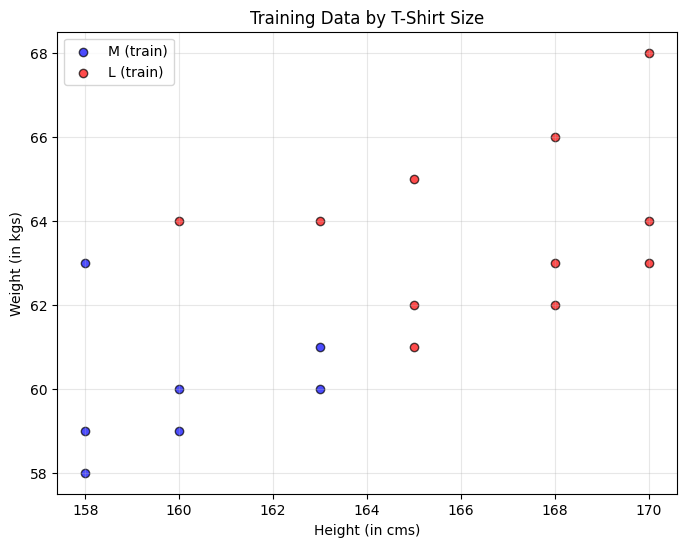

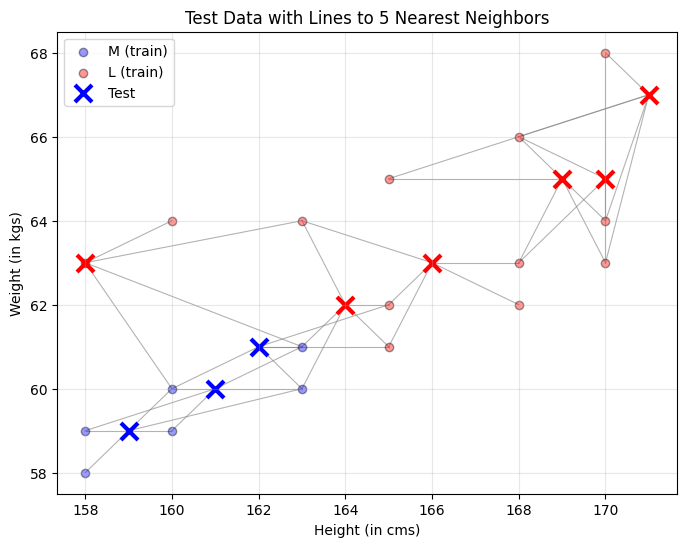

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def get_k_nearest_indices(X_train, x_query, k=5):
    distances = np.sqrt(np.sum((X_train - x_query) ** 2, axis=1))
    return np.argsort(distances)[:k]

plt.figure(figsize=(8, 6))
for size, color, label in [(1, 'blue', 'M (train)'), (2, 'red', 'L (train)')]:
    subset = df[df['T Shirt Size'] == size]
    plt.scatter(subset['Height (in cms)'], subset['Weight (in kgs)'],
                c=color, label=label, alpha=0.7, edgecolors='k')

plt.xlabel('Height (in cms)')
plt.ylabel('Weight (in kgs)')
plt.title('Training Data by T-Shirt Size')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))

for size, color, label in [(1, 'blue', 'M (train)'), (2, 'red', 'L (train)')]:
    subset = df[df['T Shirt Size'] == size]
    plt.scatter(subset['Height (in cms)'], subset['Weight (in kgs)'],
                c=color, label=label, alpha=0.4, edgecolors='k')

X_train_raw = x_train.to_numpy()
X_test_raw = X_test.to_numpy()

for i in range(len(X_test)):
    test_point = X_test_scaled[i]           
    neighbor_idx = get_k_nearest_indices(X_train_scaled, test_point, k=5)

    tx, ty = X_test_raw[i]
    color = 'blue' if y_test[i] == 1 else 'red'
    plt.scatter(tx, ty, c=color, marker='x', s=150, linewidths=3,
                label='Test' if i == 0 else "")

    for idx in neighbor_idx:
        nx, ny = X_train_raw[idx]
        plt.plot([tx, nx], [ty, ny], c='gray', linewidth=0.8, alpha=0.6, zorder=0)

plt.xlabel('Height (in cms)')
plt.ylabel('Weight (in kgs)')
plt.title('Test Data with Lines to 5 Nearest Neighbors')
plt.legend()
plt.grid(alpha=0.3)
plt.show()